#### Q1. READING OF CROP YIELD DATASET?

In [1]:
import pandas as pd

df = pd.read_csv("crop_yield.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


#### Q2. WHAT IS THE TOTAL NUMBER OF RECORDS IN THE DATASET?

In [2]:
df.shape

(1000000, 10)

#### Q3. What is the average Rainfall, Temperature, and Yield across the entire dataset?

In [3]:
df[['Rainfall_mm', 'Temperature_Celsius', 'Yield_tons_per_hectare']].mean()

Rainfall_mm               549.981901
Temperature_Celsius        27.504965
Yield_tons_per_hectare      4.649472
dtype: float64

#### Q4. Checking for missing values in the dataset?

In [4]:
print(df.isnull().sum())

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64


#### Q5. Selecting input features and target variable?

In [5]:
# Selecting correct features
X = df[['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']]
y = df['Yield_tons_per_hectare']

print("Input Features:")
print(X.head())

print("Target Variable:")
print(y.head())

Input Features:
   Rainfall_mm  Temperature_Celsius  Days_to_Harvest
0   897.077239            27.676966              122
1   992.673282            18.026142              140
2   147.998025            29.794042              106
3   986.866331            16.644190              146
4   730.379174            31.620687              110
Target Variable:
0    6.555816
1    8.527341
2    1.127443
3    6.517573
4    7.248251
Name: Yield_tons_per_hectare, dtype: float64


#### Q6. What is the average crop yield?

In [6]:
print("Average Yield:", y.mean())

Average Yield: 4.649472487663023


#### Q7. HOW MANY DIFFERENT CROPS ARE PRESENT IN THE DATASET?

In [7]:
df['Crop'].value_counts()

Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64

#### Q8. How do you identify the most frequent 'Soil_Type' in the dataset?

In [8]:
df['Soil_Type'].mode()[0]

'Sandy'

#### Q9. WHAT IS THE MAXIMUM AND MINIMUM YIELD IN THE DATASET?

In [9]:
max_yield = df['Yield_tons_per_hectare'].max()
min_yield = df['Yield_tons_per_hectare'].min()

print(f"Maximum Yield: {max_yield}")
print(f"Minimum Yield: {min_yield}")

Maximum Yield: 9.963372228814649
Minimum Yield: -1.147613222534901


#### Q10. Splitting dataset into training and testing data?

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (800000, 3)
Testing data size: (200000, 3)


#### Q11. How can you visualize the distribution of 'Days to Harvest' using a histogram?

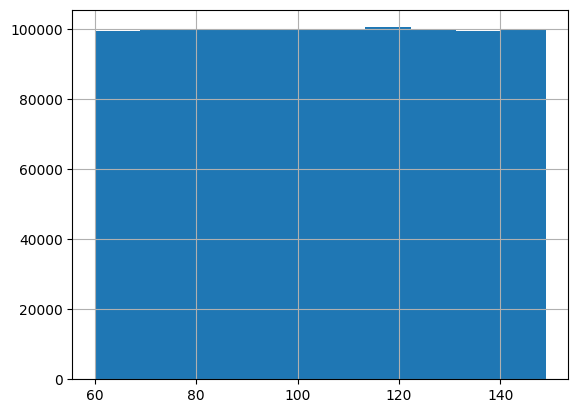

In [13]:
import matplotlib.pyplot as plt
df['Days_to_Harvest'].hist()
plt.show()

#### Q12. Finding the Region and its Total Yield?

In [14]:
# Group by 'Region' and sum the yields, then sort
region_yields = df.groupby('Region')['Yield_tons_per_hectare'].sum().sort_values(ascending=False)
print(region_yields)

# To get just the top region name
highest_region = region_yields.idxmax()
print(f"The region with the highest crop yield is: {highest_region}")

Region
North    1.164334e+06
West     1.162677e+06
South    1.162462e+06
East     1.160000e+06
Name: Yield_tons_per_hectare, dtype: float64
The region with the highest crop yield is: North


#### Q13. How can you check for outliers in the 'Yield_tons_per_hectare' using a boxplot?

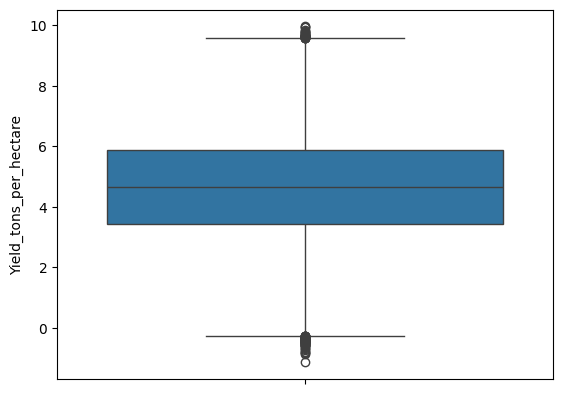

In [16]:
import seaborn as sns
sns.boxplot(df['Yield_tons_per_hectare'])
plt.show()

#### Q14. 11. Is there a visual relationship between Rainfall and Yield? (Scatter Plot)

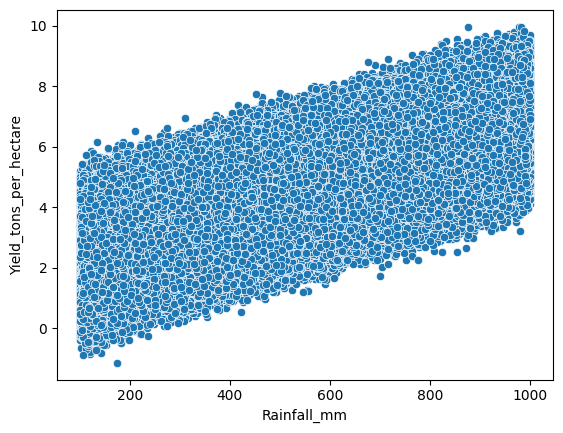

In [17]:
sns.scatterplot(x='Rainfall_mm', y='Yield_tons_per_hectare', data=df)
plt.show()

#### Q15. How do you visualize the correlation between all numerical agricultural factors?

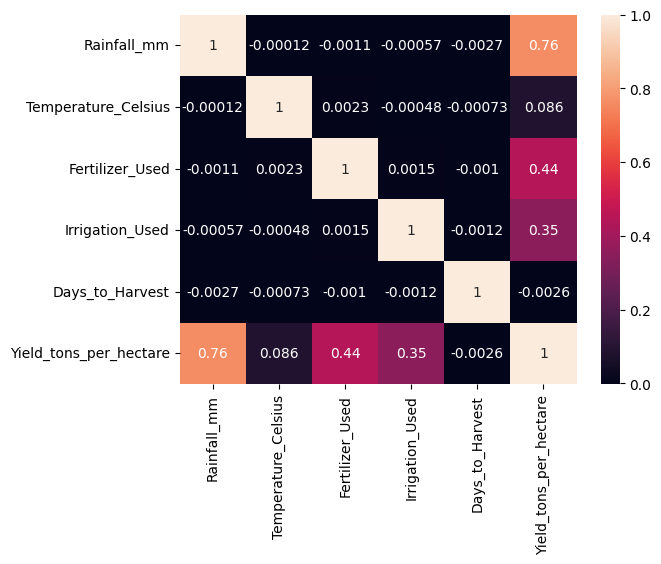

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()